# 1. Introduction
#### Modélisation avec Random Forest

**Objectif**

Cette étape consiste à entraîner un modèle Random Forest afin de prédire les quantités futures de carburant commandées par les stations-service.

Le modèle utilisera :
- les variables temporelles ;
- les comportements historiques ;
- les tendances de commande.

## 2. Importation des Bibliothèques

In [2]:
# IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Chargement du dataset ML
Le dataset contient toutes les variables préparées et les features nécessaires au modèle.

In [5]:
# CHARGEMENT DU DATASET

df = pd.read_excel("../data/propre/dataset_ml.xlsx")

print(df.shape)

display(df.head())

(33492, 24)


,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,...,Mois,Annee,JourSemaine,Weekend,Lag_1,Lag_7,Rolling_7j,Rolling_Std_7j,StationEncoded,ProduitEncoded
0,2022-10-26,A0002,C0083,CC6471,4000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,...,10,2022,2,0,10000,20000,8714.285714,3498.298906,0,1
1,2022-11-03,A0001,C0083,CC6471,15000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,...,11,2022,3,0,4000,15000,8714.285714,3498.298906,0,0
2,2022-11-04,A0002,C0083,CC6471,12000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,...,11,2022,4,0,15000,8000,9285.714286,3683.941988,0,1
3,2022-11-07,A0002,C0083,CC6471,3000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,...,11,2022,0,0,12000,10000,8285.714286,4347.960660,0,1
4,2022-11-08,A0001,C0083,CC6471,10000,PROD-BLANC,Expédition vente,2M ASSOCIES,STATION BOULEVARD MARINA,CODO,...,11,2022,1,0,3000,8000,8571.428571,4391.550328,0,0


# 4. Sélection des variables explicatives
Je définis ce que le modèle observe et ce qu’il doit prédire.

In [7]:
# VARIABLES EXPLICATIVES

features = [
    "StationEncoded",
    "ProduitEncoded",
    "Jour",
    "Mois",
    "Annee",
    "JourSemaine",
    "Weekend",
    "Lag_1",
    "Lag_7",
    "Rolling_7j",
    "Rolling_Std_7j"
]

target = "Quantité facturée"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(33492, 11)
(33492,)


## 5. Séparation Train/Test
Mon problème étant temporel, alorsDonc il faut :entraîner sur le passé ettester sur le futur.
Sinon : fuite de données et faux résultats.

In [9]:
# SEPARATION TRAIN / TEST

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (26793, 11)
Test : (6699, 11)


# 6. Construction du modèle Random Forest
Explication des paramètres

| Paramètre    | Rôle                         |
| ------------ | ---------------------------- |
| n_estimators | nombre d’arbres              |
| max_depth    | profondeur maximale          |
| random_state | reproductibilité             |
| n_jobs=-1    | utilise tous les processeurs |


In [41]:
# CONSTRUCTION DU MODELE


rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print(rf_model)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)


## 7. Entraînement du modèle

Le modèle apprend :les habitudes, les tendances et les relations historiques.

In [47]:
# ENTRAINEMENT

rf_model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


## 8. Prédictions
Le modèle tente ici d'estimer les futures commandes

In [49]:
# PREDICTIONS

predictions = rf_model.predict(X_test)

print(predictions[:10])

[4855.14643832 5192.43980593 4617.8336471  3962.93181105 4514.47295974
 4890.22406884 4267.31419255 5546.92712818 4930.50937008 4751.97902864]


## 9. Évaluation des performances

### 9.1 MAE
Le MAE mesure l’erreur moyenne absolue.

In [53]:
# MAE

mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE :", mae)

MAE : 2702.5155774127966


### 9.2 RMSE

Pénalise fortement les grosses erreurs.

In [55]:
# RMSE

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("RMSE :", rmse)

RMSE : 3677.119735621155


### 9.3 R2 SCORE

Mesure la qualité globale du modèle.

In [59]:
# R2 SCORE

r2 = r2_score(
    y_test,
    predictions
)

print("R² :", r2)

R² : 0.6255959936256459


## 10. Analyse des variables importantes
Cette étape montre quelles variables influencent le plus les commandes

In [62]:
# IMPORTANCE DES VARIABLES

importance = pd.DataFrame({
    "Variable": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Variable,Importance
9,Rolling_7j,0.711634
10,Rolling_Std_7j,0.101774
7,Lag_1,0.054620
8,Lag_7,0.030407
2,Jour,0.023697
1,ProduitEncoded,0.021969
0,StationEncoded,0.015954
3,Mois,0.015678
5,JourSemaine,0.012389
4,Annee,0.011291


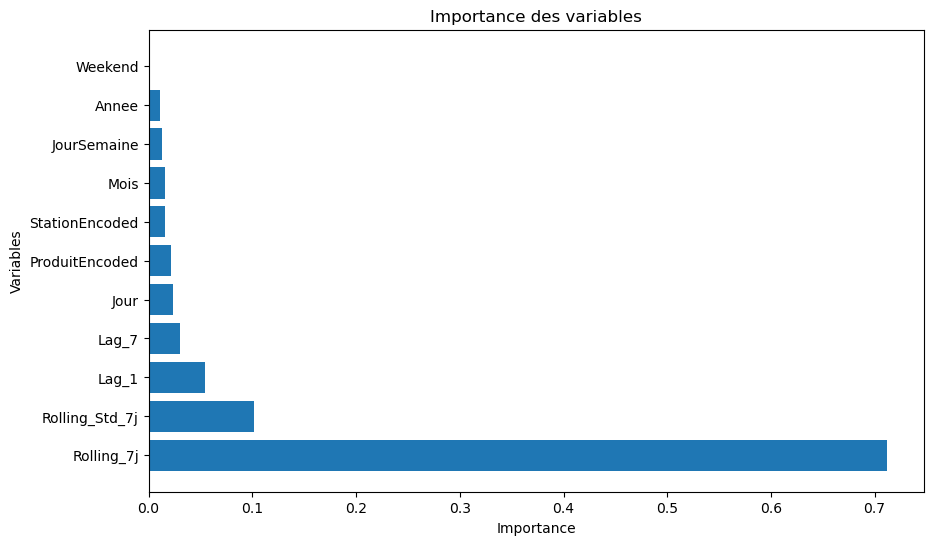

In [25]:
# VISUALISATION

plt.figure(figsize=(10,6))

plt.barh(
    importance["Variable"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variables")

plt.title("Importance des variables")

plt.show()

## 11. Comparaison Réel vs Prédit

In [66]:
# REEL VS PREDIT

comparaison = pd.DataFrame({
    "Réel": y_test.values,
    "Prédit": predictions
})

display(comparaison.head(20))

,Réel,Prédit
0,2000,4855.146438
1,5000,5192.439806
2,7000,4617.833647
3,4000,3962.931811
4,4000,4514.472960
5,7000,4890.224069
6,5000,4267.314193
7,5000,5546.927128
8,3000,4930.509370
9,5000,4751.979029


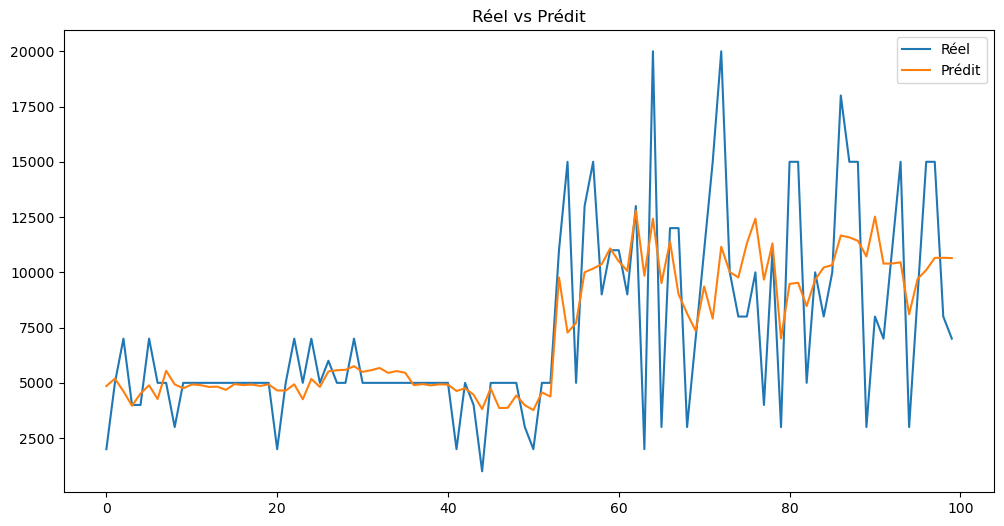

In [68]:
# GRAPHIQUE

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label="Réel"
)

plt.plot(
    predictions[:100],
    label="Prédit"
)

plt.legend()

plt.title("Réel vs Prédit")

plt.show()

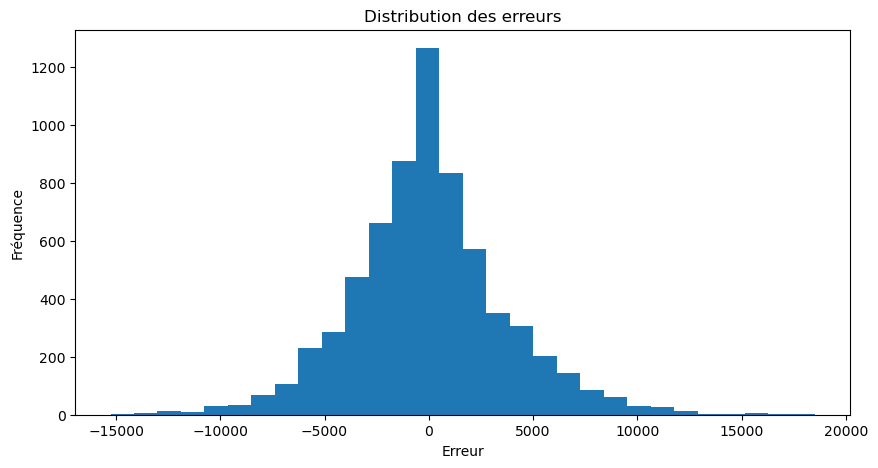

In [78]:
# Distribution des erreurs

errors = y_test - predictions

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("Distribution des erreurs")

plt.xlabel("Erreur")
plt.ylabel("Fréquence")

plt.show()

### Commentaire et interprétation du graphique de distribution des erreurs

Le graphique présenté représente la distribution des erreurs du modèle Random Forest, c’est-à-dire la différence entre les valeurs réelles et les valeurs prédites.

Une erreur proche de zéro signifie que la prédiction du modèle est très proche de la réalité.

**Analyse générale de la distribution**

La distribution observée présente une forme globalement centrée autour de zéro, avec une apparence proche d’une distribution normale.

Cela indique que :
- le modèle ne présente pas de biais majeur ;
- les prédictions sont globalement équilibrées ;
- les erreurs positives et négatives sont relativement réparties de manière symétrique.

Le fait que la majorité des erreurs soient concentrées autour de zéro montre que le modèle effectue généralement des prédictions proches des valeurs réelles.

**Concentration des erreurs**

On observe que la plus grande fréquence des erreurs se situe dans l’intervalle proche de :
- -3000 à +3000 litres environ.

Cela signifie que, dans la majorité des cas, les écarts entre les quantités réelles et prédites restent relativement modérés.

Cette observation confirme les résultats obtenus avec le MAE et le RMSE.

**Présence de valeurs extrêmes**

Le graphique montre également quelques erreurs importantes situées aux extrémités de la distribution, notamment :
- au-delà de ±10000 litres.

Ces erreurs extrêmes peuvent être dues à :
- des commandes exceptionnelles ;
- des variations soudaines de consommation ;
- des comportements atypiques de certaines stations ;
- des événements non pris en compte dans les variables du modèle.

Cependant, leur fréquence reste relativement faible comparée à l’ensemble des observations.

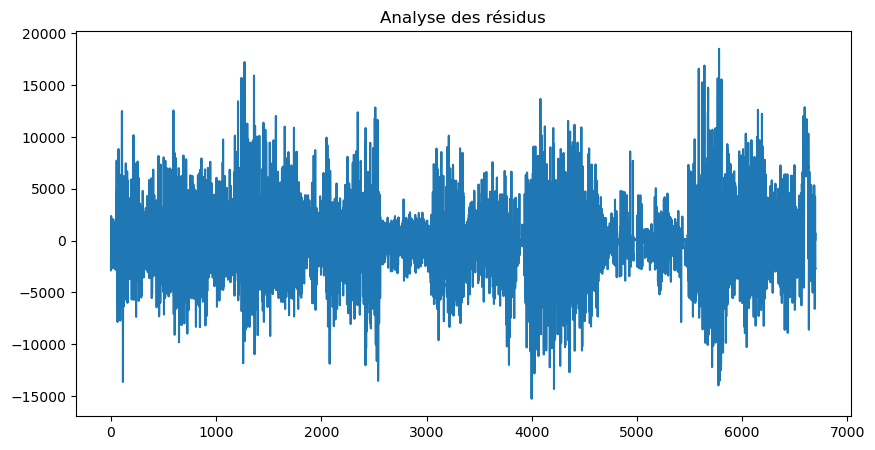

In [85]:
residus = y_test - predictions

plt.figure(figsize=(10,5))

plt.plot(residus.values)

plt.title("Analyse des résidus")

plt.show()

L'analyse des résidus confirme bien les comportements précédents du modèle 

## 12. Sauvegarde du modèle

Le modèle pourra être :réutilisé, intégré dans Streamlit, déployé.

In [71]:
# SAUVEGARDE

import joblib

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

print("Modèle sauvegardé.")

Modèle sauvegardé.


## 13. Conclusion

**Conclusion et interprétation des résultats du modèle Random Forest** 

Le modèle Random Forest développé dans cette étude a permis de prédire les quantités de carburant commandées par les stations-service à partir des historiques de commandes et des variables temporelles construites lors du feature engineering.

L’objectif principal était d’anticiper les besoins futurs des stations afin d’améliorer la planification logistique et l’approvisionnement en carburant.

**Analyse des performances du modèle**

L’évaluation du modèle a été réalisée à l’aide des métriques suivantes :

- MAE = 2702.52
- RMSE = 3677.12
- R² = 0.626

**Interprétation du MAE**

Le MAE (Mean Absolute Error) obtenu est de 2702.52.

Cela signifie qu’en moyenne, les prédictions du modèle s’écartent d’environ 2703 litres par rapport aux quantités réellement commandées.

Compte tenu des volumes généralement importants dans le secteur pétrolier, cette erreur reste raisonnable et montre que le modèle parvient à capturer une partie importante des comportements de commande des stations-service.

Le modèle fournit donc des prévisions exploitables pour l’aide à la décision logistique.

**Interprétation du RMSE**

Le RMSE obtenu est de 3677.12.

Cette métrique étant plus sensible aux grandes erreurs, elle montre que certaines prédictions présentent encore des écarts importants.

Cela peut s’expliquer par :
- des variations brutales de consommation ;
- des commandes exceptionnelles ;
- des comportements irréguliers de certaines stations ;
- des facteurs externes non pris en compte dans les données.

Cependant, le RMSE reste globalement cohérent avec le MAE, ce qui indique que le modèle reste relativement stable.

**Interprétation du coefficient R²**

Le coefficient R² obtenu est de 0.626.

Cela signifie que le modèle explique environ 62.6 % de la variabilité des quantités commandées.

Ce résultat montre que le modèle possède une capacité prédictive satisfaisante, même si une partie des variations reste encore inexpliquée.

Dans un contexte réel de données métier et de séries temporelles complexes, un R² supérieur à 0.6 constitue déjà un résultat encourageant.

Le modèle réussit donc à apprendre une grande partie des comportements historiques des stations-service.

**Analyse des variables importantes**

L’analyse des importances des variables montre que les variables historiques dominent très largement les prédictions.

| Variable | Importance |
|---|---|
| Rolling_7j | 0.7116 |
| Rolling_Std_7j | 0.1018 |
| Lag_1 | 0.0546 |
| Lag_7 | 0.0304 |


**Interprétation métier des résultats**

**Rolling_7j** : variable la plus importante

La moyenne mobile sur 7 jours représente plus de **71 %** de l’importance totale du modèle.

Cela montre que les tendances récentes de consommation sont le facteur le plus déterminant dans la prévision des commandes.

Autrement dit, les stations-service ont des comportements relativement stables à court terme, et les commandes futures dépendent fortement des consommations récentes.

Cette observation est cohérente avec le fonctionnement réel des stations-service, où les approvisionnements suivent généralement les niveaux récents de vente et de stock.

**Rolling_Std_7j**

Cette variable mesure la variabilité récente des commandes.

Son importance indique que le modèle tient également compte de la stabilité ou de l’instabilité des comportements de commande.

Les stations ayant des consommations très irrégulières influencent donc fortement les prévisions.

**Lag_1**

La quantité précédemment commandée joue aussi un rôle important.

Cela confirme que les commandes passées influencent directement les commandes futures.

Le modèle exploite donc efficacement la dépendance temporelle des données.


**Variables calendaires**

Les variables comme :
- Jour,
- Mois,
- JourSemaine,
- Weekend

présentent des importances relativement faibles.

Cela suggère que les comportements de commande dépendent davantage :
- des tendances récentes de consommation,
que :
- des effets calendaires.

Les habitudes de commande semblent donc principalement pilotées par les besoins opérationnels des stations.

**Analyse globale du modèle**

Le modèle Random Forest présente plusieurs points positifs :

- bonne capacité d’apprentissage ;
- robustesse face au bruit ;
- bonne gestion des relations non linéaires ;
- bonne interprétabilité ;
- exploitation efficace des historiques.

Le modèle parvient globalement à reproduire les comportements historiques des stations-service.

**Limites observées**

Certaines limites restent néanmoins présentes :

- difficulté à prévoir certaines variations soudaines ;
- absence de variables externes :
  - jours fériés ;
  - ruptures de stock ;
  - événements économiques ;
  - fluctuations exceptionnelles ;
- capacité limitée à modéliser explicitement les dépendances temporelles complexes.

Ces limites expliquent pourquoi une partie de la variabilité reste non expliquée.

**Conclusion générale**

Le modèle Random Forest fournit des résultats satisfaisants pour une première approche prédictive des commandes de carburant.

Les résultats obtenus montrent que les historiques de consommation et les tendances récentes jouent un rôle majeur dans l’anticipation des besoins des stations-service.

Le modèle constitue ainsi une base solide pour :
- l’optimisation logistique ;
- la planification des livraisons ;
- la réduction des risques de rupture de stock.

Cette première modélisation servira également de référence comparative pour les modèles plus avancés tels que :
- XGBoost ;
- ARIMA ;
- Prophet.